## The NDVI index

In this notebook I will asses the health of the vegetation of a certain geographic area by studying how the NDVI index evolves over a period of time.

The Normalized Difference Vegetation Index (NDVI) is a satellite-derived metric
used to quantify vegetation health and density across the Earth's surface. It is
calculated from the red (B04) and near-infrared (B08) reflectance bands captured
by sensors such as Sentinel-2:

NDVI = (B08 − B04) / (B08 + B04)

Healthy vegetation strongly absorbs red light for photosynthesis while reflecting
near-infrared radiation, producing high NDVI values. Bare soil, urban surfaces,
and water behave very differently in these bands, resulting in distinctly lower
or negative values.

Values range from −1 to +1:

| Land cover type | Typical NDVI range |
|---|---|
| Open water / sea | −0.5 – 0.0 |
| Urban / built-up areas | 0.0 – 0.15 |
| Bare soil / desert | 0.05 – 0.20 |
| Sparse / stressed vegetation | 0.15 – 0.35 |
| Cropfields (growing season) | 0.35 – 0.60 |
| Dense, healthy vegetation | 0.60 – 1.00 |

Water bodies return negative values because liquid water absorbs near-infrared
strongly while reflecting some red light, inverting the ratio. Urban areas score
near zero due to the spectrally neutral response of concrete and asphalt. Cropfields
show highly variable NDVI across the agricultural calendar — peaking during the
growing season and dropping sharply after harvest — making them a useful benchmark
for comparing against natural vegetation dynamics. In semi-arid regions like the
Sahel, NDVI rarely exceeds 0.45, so even modest positive trends detected through
multi-year time series carry significant ecological meaning and serve as key
indicators of regreening progress.

In [1]:
# import needed libraries
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import datetime

If needed, install sentinelhub library

In [3]:
# pip install sentinelhub

and then import the necessary modules

In [5]:
from sentinelhub import (
    SHConfig,
    DataCollection,
    SentinelHubCatalog,
    SentinelHubRequest,
    BBox,
    bbox_to_dimensions,
    CRS,
    MimeType,
    MosaickingOrder,
)

set up SentinelHub configuration with your corresponding client_id and client_secret

In [7]:
config = SHConfig()
config.sh_client_id = getpass.getpass("Enter your SentinelHub client id")
config.sh_client_secret = getpass.getpass("Enter your SentinelHub client secret")
config.sh_token_url = "https://identity.dataspace.copernicus.eu/auth/realms/CDSE/protocol/openid-connect/token"
config.sh_base_url = "https://sh.dataspace.copernicus.eu"
config.save("cdse")

Enter your SentinelHub client id ········
Enter your SentinelHub client secret ········


### Request data and compute NDVI 
Define function to request data from sentinel and process it to compute NDVI data

In [9]:
def get_ndvi_mat(coords, resolution, dates, config):
    """Function that returns the NDVI index
    inputs:
        - coords: Coordinate box delimiting the square over which to compute the NDVI index
        - resolution: Resolution of the requested data
        - dates: Dates delimiting the time span over which the data is requested. The function computes the NDVI index on the less cloudy day within that period of time
        - config: SentinelHub configuration
    outputs:
        - ndvi_mat: array containing the computed NDVI index over the specified coordinate box and dates
    """


    # SentinelHub specifications
    m_bbox = BBox(bbox = coords, crs=CRS.WGS84)
    m_size = bbox_to_dimensions(m_bbox, resolution = resolution)
    catalog = SentinelHubCatalog(config = config)

    # select NIR (B08) and RED (B04) channels from sentinel data
    evalscript_ndvi = """
        //VERSION=3
        function setup() {
            return {
                input: [{
                    bands: ["B04","B08"],
                    units: "DN"
                }],
                output: {
                    bands: 2,
                    sampleType: "INT16"
                }
            };
        }
    
        function evaluatePixel(sample) {
            return [sample.B04, sample.B08];
        }
    """

    # define requesting function
    request_ndvi = SentinelHubRequest(
        evalscript = evalscript_ndvi,
        input_data=[
            SentinelHubRequest.input_data(
                data_collection=DataCollection.SENTINEL2_L1C.define_from(
                    "s2l1c", service_url=config.sh_base_url
                ),
                time_interval=(dates[0], dates[1]),
                mosaicking_order=MosaickingOrder.LEAST_CC,
            )
        ],
        responses=[SentinelHubRequest.output_response("default", MimeType.TIFF)],
        bbox = m_bbox,
        size = m_size,
        config = config,
    )

    # request data from SentinelHub
    data = request_ndvi.get_data()

    # process NIR and RED chanels' data into NDVI index
    n = data[0].reshape(data[0].shape[0] * data[0].shape[1], 2)
    df = pd.DataFrame(n)
    df.columns = ['red', 'nir']
    df['ndvi'] = (df.nir - df.red) / (df.nir + df.red)
    # df.head()

    # reshape into matrix for plotting purposes
    ndvi_mat = df.ndvi.to_numpy()
    ndvi_mat = ndvi_mat.reshape(data[0].shape[0], data[0].shape[1])

    return ndvi_mat


### The Balearic Islands

Let us first focus on the NDVI index over Sant Antoni de Portmany, on the Balearic Islands, in order to get familiar with the behaviour of the NDVI index.

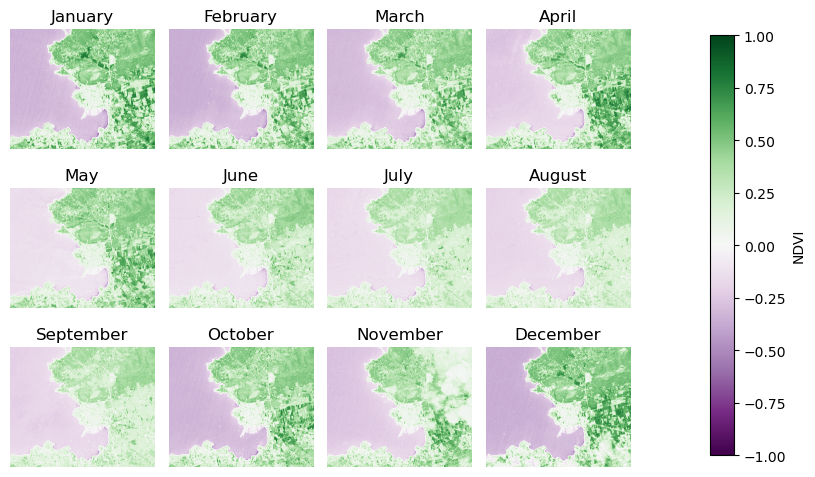

In [11]:
# select the dates: to inspect the seasonal differences, we will request data for each month over a period of one year
dates_vec = [["2022-01-01", "2022-01-27"],
            ["2022-02-01", "2022-02-27"],
            ["2022-03-01", "2022-03-27"],
            ["2022-04-01", "2022-04-27"],
            ["2022-05-01", "2022-05-27"],
            ["2022-06-01", "2022-06-27"],
            ["2022-07-01", "2022-07-27"],
            ["2022-08-01", "2022-08-27"],
            ["2022-09-01", "2022-09-27"],
            ["2022-10-01", "2022-10-27"],
            ["2022-11-01", "2022-11-27"],
            ["2022-12-01", "2022-12-27"]]

# select the coordinate box (Sant Antoni de Portmany)
coords = [1.269062, 38.965816, 1.32569, 39.003978]
resolution = 2


fig, axes = plt.subplots(nrows=3, ncols=4, figsize = [8, 6])
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']
for month, dates, ax in zip(months, dates_vec, axes.flat):
    # request data from SentinelHub and compute NDVI index
    ndvi_mat = get_ndvi_mat(coords, resolution, dates, config)

    # plot results
    im = ax.imshow(ndvi_mat, vmin=-1, vmax=1, cmap = 'PRGn')
    ax.set_title(month)
    ax.axis('off')

fig.subplots_adjust(wspace = .1, hspace = .1)
cbar_ax = fig.add_axes([1, 0.15, 0.03, 0.7])
fig.colorbar(im, cax=cbar_ax, label = 'NDVI')
plt.show()


The negative NDVI values correspond to water (left half of the image). In the center of the image we see the town of Sant Antoni de Portmany, identified by NDVI values close to zero throughout the whole year. To its right there are cropfields, which have higher NDVI values in the colder periods of the year, since the warm summers of this island's arid mediterranean climate are usually characterised by more yellowish landscapes.

Let us now zoom in and take a closer look at how the NDVI index evolves in this specific cropfield region.

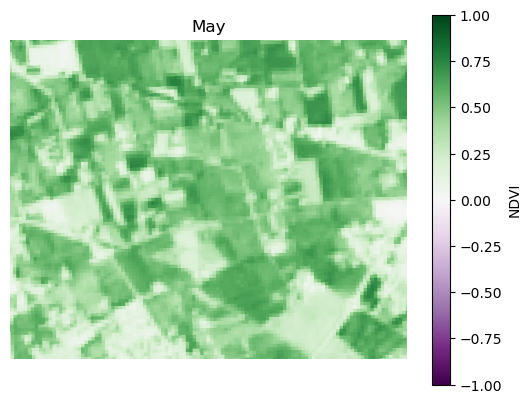

In [14]:
# zoom in to see the cropfields area

# select the dates and area's coordinates
dates = ["2022-05-01", "2022-05-21"]
coords = [1.309653, 38.971822, 1.322738, 38.980362]
resolution = 2

ndvi_mat = get_ndvi_mat(coords, resolution, dates, config)

fig, ax = plt.subplots()
im = ax.imshow(ndvi_mat, vmin=-1, vmax=1, cmap = 'PRGn')
ax.axis('off')
ax.set_title('May')
fig.colorbar(im, label = 'NDVI')

plt.show()

In [16]:
# define a dataframe containing the NDVI index of each pixel over the region, for the whole year period 
dates_vec = [["2022-1-01", "2022-1-27"],
            ["2022-2-01", "2022-2-27"],
            ["2022-3-01", "2022-3-27"],
            ["2022-4-01", "2022-4-27"],
            ["2022-5-01", "2022-5-27"],
            ["2022-6-01", "2022-6-27"],
            ["2022-7-01", "2022-7-27"],
            ["2022-8-01", "2022-8-27"],
            ["2022-9-01", "2022-9-27"],
            ["2022-10-01", "2022-10-27"],
            ["2022-11-01", "2022-11-27"],
            ["2022-12-01", "2022-12-27"]]
months = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

df = []
for dates in dates_vec:
    ndvi_mat = get_ndvi_mat(coords, resolution, dates, config)
    df.append(ndvi_mat.flatten())

df = pd.DataFrame(df).T
df.columns = months
df.head()

,January,February,March,April,May,June,July,August,September,October,November,December
0,0.648392,0.460272,0.471041,0.593553,0.621694,0.591342,0.575055,0.567385,0.592680,0.613883,0.298135,0.596434
1,0.648392,0.460272,0.471041,0.593553,0.621694,0.591342,0.575055,0.567385,0.592680,0.613883,0.298135,0.596434
2,0.648392,0.460272,0.471041,0.593553,0.621694,0.591342,0.575055,0.567385,0.592680,0.613883,0.298135,0.596434
3,0.692905,0.608659,0.499294,0.592671,0.548603,0.500111,0.428961,0.427386,0.458993,0.587447,0.275604,0.498982
4,0.692905,0.608659,0.499294,0.592671,0.548603,0.500111,0.428961,0.427386,0.458993,0.587447,0.275604,0.498982


We can now average the NDVI index over the whole area and use it as a measure of the health of the vegetation. Let us plot how this health measure evolves along the year

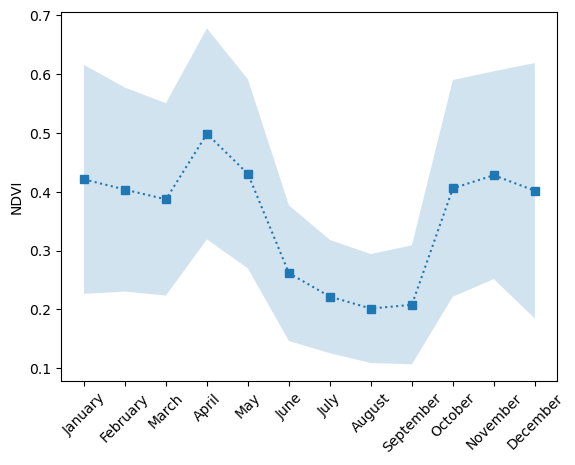

In [18]:
fig, ax = plt.subplots()
# ax.errorbar(months, df.mean(axis = 0), yerr = df.std(axis = 0), marker = 'o', linestyle = ':', capsize = 5)
ax.plot(months, df.mean(axis = 0), marker = 's', linestyle = ':')
ax.fill_between(months, df.mean(axis = 0) - df.std(axis = 0), df.mean(axis = 0) + df.std(axis = 0), alpha=0.2)
ax.tick_params("x", rotation=45)
ax.set_ylabel('NDVI')
plt.show()

The shaded area represents the standard deviation over the mean value.

We confirm that there's less green vegetation, characterised by lower (but positive) NDVI values, during the summer period.

### Regreening efforts in the Sahel

The Sahel region, spanning areas across the sub-saharan Africa from Senegal to Eritrea, has long been threatened by desertification, drought, and land degradation. Large scale regreening efforts such as the Great Green Wall project have aimed to restore it and improve soil fertility.

In this second part I study the evolution of the NDVI index over the last decade in a small area of the Sahel, namely the Ferlo desert.

Let us download all the available data from 2016 to the current date.

In [26]:
# define dates, spanning all available data
dates_vec = []
dates_lbl = []
now = datetime.datetime.now()
months = np.arange(1, 13)
years = np.arange(2016, now.year + 1)
for year in years:
    if year == now.year:
        months = np.arange(1, now.month)
    for month in months:
        dates_vec.append([str(year) + "-" + str(month) + "-01", str(year) + "-" + str(month) + "-27"])
        dates_lbl.append(str(year) + "-" + str(month))

In [28]:
# get NDVI matrices for each date
coords = [-15.478352182991873, 15.724966180235272, -15.358911391047574, 15.598739936074185]
resolution = 40
df = []
for dates in dates_vec:
    # print(dates)
    ndvi_mat = get_ndvi_mat(coords, resolution, dates, config)
    df.append(ndvi_mat.flatten())

df = pd.DataFrame(df).T
df.columns = dates_lbl
df.head()

,2016-1,2016-2,2016-3,2016-4,2016-5,2016-6,2016-7,2016-8,2016-9,2016-10,...,2025-6,2025-7,2025-8,2025-9,2025-10,2025-11,2025-12,2026-1,2026-2,2026-3
0,0.127286,0.125191,0.123356,0.092787,0.096051,0.099712,0.060386,0.161040,0.198889,0.148083,...,0.085467,0.086376,0.086832,0.159511,0.174672,0.138987,0.141834,0.128917,0.135002,0.138064
1,0.114296,0.121017,0.102777,0.091024,0.107172,0.105011,0.102426,0.161413,0.215735,0.149175,...,0.086736,0.079805,0.084762,0.157545,0.175059,0.145725,0.141649,0.131233,0.137333,0.142058
2,0.114482,0.119585,0.106310,0.091530,0.100163,0.085395,0.082257,0.154884,0.210278,0.144604,...,0.069499,0.078264,0.070321,0.142302,0.148511,0.125160,0.114631,0.103611,0.122555,0.121892
3,0.109157,0.113170,0.100968,0.094544,0.095138,0.087912,0.068009,0.146234,0.210127,0.136882,...,0.075089,0.077311,0.074594,0.142459,0.153524,0.121522,0.115578,0.114798,0.126263,0.126833
4,0.119398,0.116505,0.107476,0.089552,0.094358,0.084197,0.080456,0.155690,0.230126,0.146901,...,0.072721,0.081262,0.073268,0.153344,0.156239,0.133003,0.124185,0.109684,0.127673,0.129042


And plot the results, computing its trend.

trend = 4.4e-05 month^-1


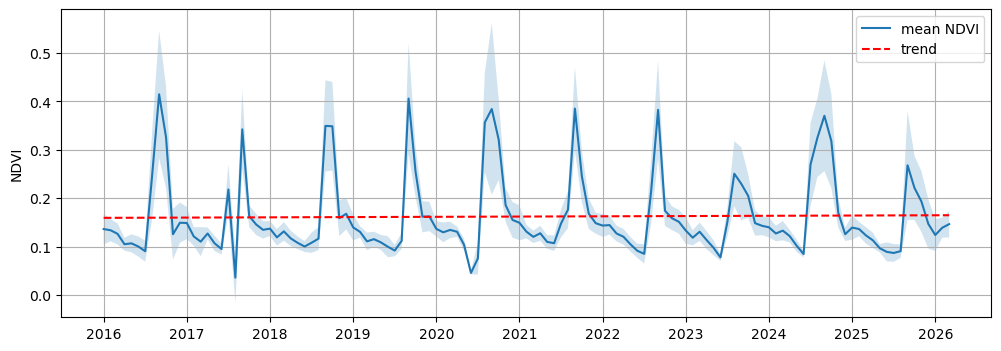

In [31]:
fig, ax = plt.subplots(figsize = [12, 4])
mean = df.mean(axis = 0)
std = df.std(axis = 0)
t = np.arange(len(dates_vec))
m, c = np.polyfit(t, mean, 1)
trend = m * t + c
print('trend =', np.round(m, 6), 'month^-1')


ax.plot(t, mean, label = 'mean NDVI')
ax.fill_between(np.arange(len(dates_vec)), mean - std, mean + std, alpha=0.2)
ax.plot(t, trend, 'r--', label = 'trend')
ax.set_ylabel('NDVI')
ax.legend()
ax.set_xticks(t[t%12 == 0], years)

plt.grid()
plt.show()

Notice the strong seasonality of the index, characterised by much more vegetation over the wet season.

By taking a look at the trend over the last decade, we observe a slight year-to-year increase of the NDVI index, suggesting the re-greening efforts are successful.